In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import ast
import os
from tqdm import tqdm

import torch

from scipy.stats import pearsonr, spearmanr, zscore

In [2]:
data_path = '../optimized/predict_notebooks/curves'
weight_path = '../train_notebooks/weights'

models = ['original', 'extendedBase', 'extended_double', 'extended_doublemlp']

In [3]:
df_full = pd.read_parquet('../sorted_data.parquet')

In [4]:
import numpy as np
from dtaidistance import dtw

def similarity(data):
    data = np.asarray(data)
    a = data[0]
    b = data[1]
    return dtw.distance_fast(a, b)

In [5]:
from src.models.optimized.extendedMLDist import Ex2VecExtendedMLP

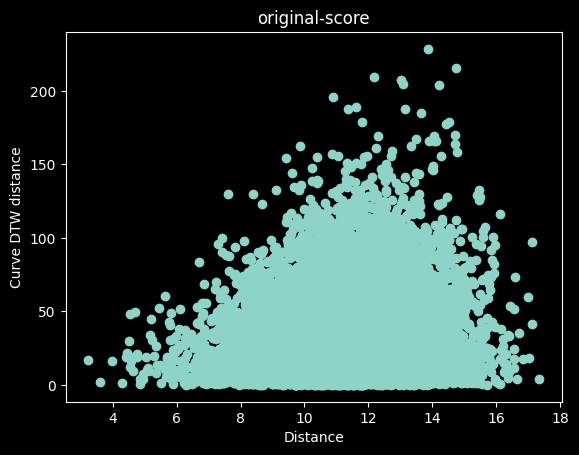

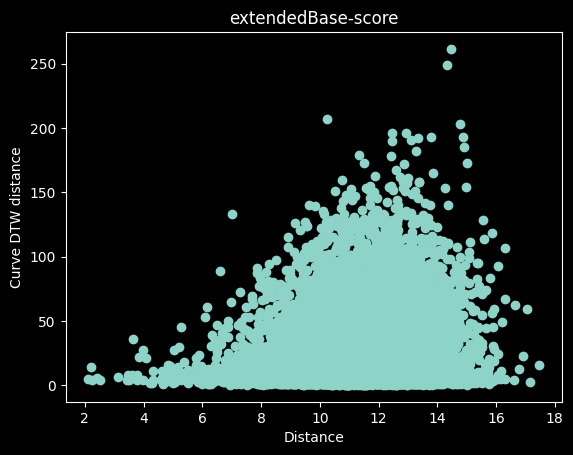

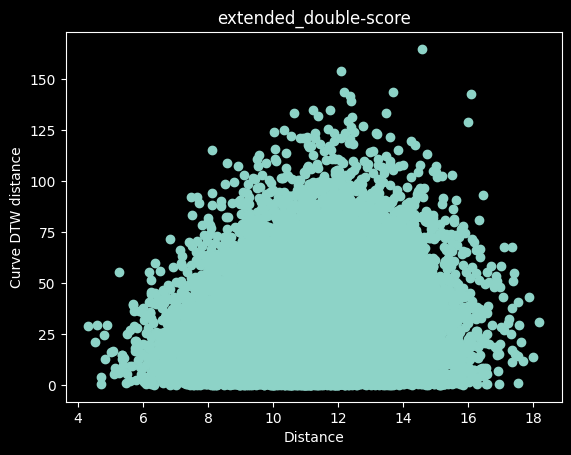

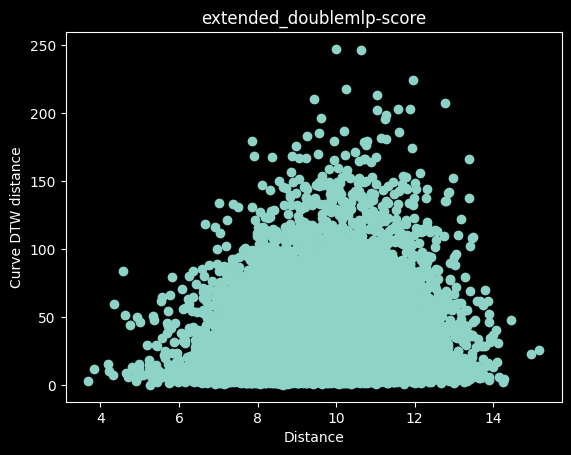

In [6]:
def interpolate_array(arr):
    arr_float = arr.astype(float)
    valid = ~np.isnan(arr_float)
    indices = np.arange(len(arr_float))
    arr_float[np.isnan(arr_float)] = np.interp(indices[np.isnan(arr_float)], indices[valid], arr_float[valid])
    return arr_float

for m in models:
    df_list = []
    weights_list = []

    weights = torch.load(f'{weight_path}/{m}/weights.pt', map_location='cpu', weights_only=False)

    emb_items = weights['model_state_dict']['embedding_item.weight'].numpy()

    df_path = f'{data_path}/{m}_predictions_for_curves.csv'
    df = pd.read_csv(df_path)

    df['score'] = df['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
    df['prob'] = df['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
    df['item'] = df['item'].astype(int)
    df['user'] = df['user'].astype(int)




    df_grouped = df.groupby(['user']).agg(
            score=('score', similarity),
            prob=('prob', similarity),
            item_dist=('item', lambda x: np.linalg.norm(emb_items[x.iloc[0], :] - emb_items[x.iloc[1], :]))
        )


    df_shorten = df_grouped.dropna()

    plt.figure()
    plt.scatter(df_shorten['item_dist'], df_shorten['score'])
    plt.title(f'{m}-score')
    plt.xlabel('Distance')
    plt.ylabel('Curve DTW distance')


    # plt.figure()
    # plt.scatter(df_shorten['item_dist'], df_shorten['prob'])
    # plt.title(f'{m}-prob')
    # plt.xlabel('Distance')
    # plt.ylabel('Curve correlation')

    df_shorten.to_csv(f'../optimized/analysis/curve_sim_{m}_dtw.csv')

In [7]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def get_dist_weight(dist, smooth, force):
    return sigmoid(smooth / (1 + dist) - force * smooth) / sigmoid(smooth - force * smooth)

def get_weighted_dist(dist, smooth, force):
    return 1 / (1 + dist) * get_dist_weight(dist, smooth, force)

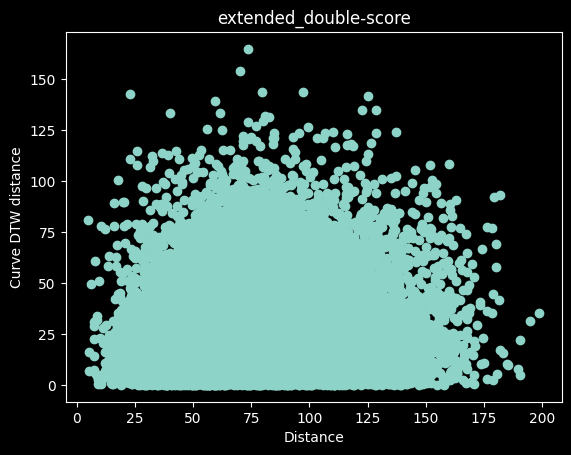

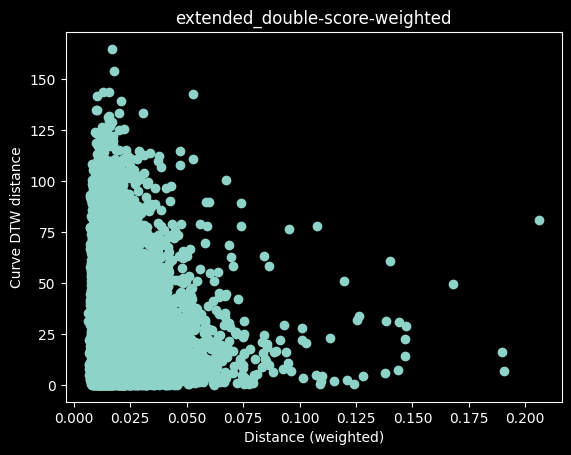

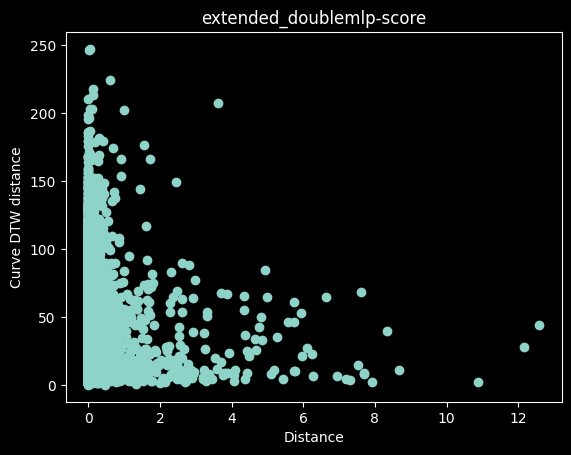

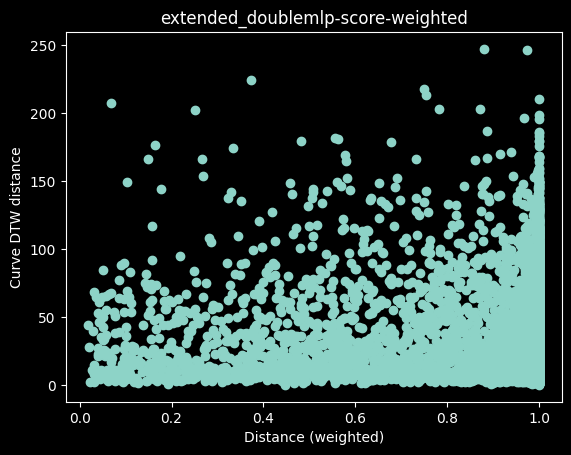

In [8]:
for m in ['extended_double', 'extended_doublemlp']:
    df_list = []
    weights_list = []

    weights = torch.load(f'{weight_path}/{m}/weights.pt', map_location='cpu', weights_only=False)

    smooth = weights['model_state_dict']['smooth'].cpu().numpy()
    force = weights['model_state_dict']['force'].cpu().numpy()

    emb_items = weights['model_state_dict']['embedding_item_extension.weight'].numpy()

    df_path = f'{data_path}/{m}_predictions_for_curves.csv'
    df = pd.read_csv(df_path)

    df['score'] = df['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
    df['prob'] = df['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
    df['item'] = df['item'].astype(int)
    df['user'] = df['user'].astype(int)

    if m == 'extended_doublemlp':
        max_history = 3500
        user_count = df_full['user_id'].max()
        item_count = df_full['track_id'].max()

        device = 'cpu'
        config = {'n_users': user_count, 'n_items': item_count, 'latent_d': 64,
                  'pretrained_embeddings_path': r'Z:/Skola/ING/Recommenders/repo/Ex2VecExtended/split_data/track_embeddings.parquet',
                  'item_mapping': r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\split_data\item_mapping.json',
                  'mlp_dist_conf': {
                    'emb_dim': 128,
                    'hidden_dims':[256, 128],
                    'block_size':512,
                    'activation':torch.nn.ReLU,
                    'dropout':0.1,
                    'positive_output':True
                  }}


        model = Ex2VecExtendedMLP(config)
        model.load_state_dict(weights["model_state_dict"], strict=False)
        model.to(device)

        model.eval()
        item_dist_matrix = model.metric(model.embedding_item_extension.weight).detach().cpu().numpy()

        df_grouped = df.groupby(['user']).agg(
                score=('score', similarity),
                prob=('prob', similarity),
                item_dist=('item', lambda x: item_dist_matrix[x.iloc[0], x.iloc[1]]),
                item_dist_weighted=('item', lambda x: get_weighted_dist(item_dist_matrix[x.iloc[0], x.iloc[1]], smooth, force))
            )
    else:

        df_grouped = df.groupby(['user']).agg(
                score=('score', similarity),
                prob=('prob', similarity),
                item_dist=('item', lambda x: np.linalg.norm(emb_items[x.iloc[0], :] - emb_items[x.iloc[1], :])),
                item_dist_weighted=('item', lambda x: get_weighted_dist(np.linalg.norm(emb_items[x.iloc[0], :] - emb_items[x.iloc[1], :]), smooth, force))
            )


    df_shorten = df_grouped.dropna()

    plt.figure()
    plt.scatter(df_shorten['item_dist'], df_shorten['score'])
    plt.title(f'{m}-score')
    plt.xlabel('Distance')
    plt.ylabel('Curve DTW distance')

    plt.figure()
    plt.scatter(df_shorten['item_dist_weighted'], df_shorten['score'])
    plt.title(f'{m}-score-weighted')
    plt.xlabel('Distance (weighted)')
    plt.ylabel('Curve DTW distance')

    # plt.figure()
    # plt.scatter(df_shorten['item_dist'], df_shorten['prob'])
    # plt.title(f'{m}-prob')
    # plt.xlabel('Distance')
    # plt.ylabel('Curve correlation')

    df_shorten.to_csv(f'../optimized/analysis/curve_sim_{m}_extended_dtw.csv')

In [9]:
models_double = ['extendedDoubleBase', 'extendedDoubleEmb', 'extendedDoubleEmbFreeze']


for m in models_double:
    df_list = []
    weights_list = []
    dir_path = f'{data_path}/{m}'
    for split in tqdm(splits):
        weights = torch.load(f'{weight_path}/{m}/split_{split}/checkpoint_best.pt', map_location='cpu')
        emb_items_base = weights['model_state_dict']['embedding_item_base.weight'].numpy()
        emb_items_ext = weights['model_state_dict']['embedding_item_extension.weight'].numpy()
        path = os.path.join(dir_path, f'split_{split}.csv')
        df = pd.read_csv(path)
        df['split'] = split
        df['score'] = df['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x))))
        df['prob'] = df['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x))))
        df['item'] = df['item'].astype(int)
        df['user'] = df['user'].astype(int)
        df_list.append(df.groupby(['user', 'split']).agg(
            score=('score', similarity),
            prob=('prob', similarity),
            item_dist_base=('item', lambda x: np.linalg.norm(emb_items_base[x.iloc[0], :] - emb_items_base[x.iloc[1], :])),
            item_dist_ext=('item', lambda x: np.linalg.norm(emb_items_ext[x.iloc[0], :] - emb_items_ext[x.iloc[1], :]))
        ).reset_index(level="split"))

    pd.concat(df_list, ignore_index=True).to_csv(f'../analysis/sim_analysis/dtw_{m}.csv')

NameError: name 'splits' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# Example 2D scatter data
X = out_df['item_dist'].to_numpy()
Y = out_df['prob'].to_numpy()

# --- Step 1: Fit linear regression using statsmodels ---
X_sm = sm.add_constant(X)  # adds intercept term
model = sm.OLS(Y, X_sm)    # Ordinary Least Squares
results = model.fit()       # Fit the model

# --- Step 2: Regression results ---
print(results.summary())

# --- Step 3: Plot data and regression line ---
plt.scatter(X, Y, label='Data')
plt.plot(X, results.predict(X_sm), color='red', label='Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression')
plt.legend()
plt.show()

# --- Optional Step 4: Residual analysis ---
residuals = Y - results.predict(X_sm)
plt.scatter(X, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('X')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
X_poly = np.column_stack((X, X**2))
X_poly = sm.add_constant(X_poly)  # add intercept

model_poly = sm.OLS(Y, X_poly)
results_poly = model_poly.fit()
print(results_poly.summary())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# Example 2D scatter data
X = out_df['item_dist'].to_numpy()
Y = out_df['prob'].to_numpy()

# --- Step 1: Fit linear regression using statsmodels ---
X_sm = sm.add_constant(X)  # adds intercept term
model = sm.OLS(Y, X_sm)    # Ordinary Least Squares
results = model.fit()       # Fit the model

# --- Step 2: Regression results ---
print(results.summary())

# --- Step 3: Plot data and regression line ---
plt.scatter(X, Y, label='Data')
plt.plot(X, results.predict(X_sm), color='red', label='Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression')
plt.legend()
plt.show()

# --- Optional Step 4: Residual analysis ---
residuals = Y - results.predict(X_sm)
plt.scatter(X, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('X')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
out_df.sort_values('score')

In [ ]:
out_df['score'].min()

In [ ]:
np.diff(df[(df['user'] == 117)].iloc[0, 2])

In [ ]:
plt.plot(np.diff(df[(df['user'] == 117)].iloc[0, 2]))
plt.plot(np.diff(df[(df['user'] == 117)].iloc[1, 2]))

In [ ]:
plt.plot(df[(df['user'] == 7870)].iloc[0, 3])
plt.plot(df[(df['user'] == 7870)].iloc[1, 3])

In [ ]:
out_df.sort_values('score')

In [ ]:
plt.plot(df[(df['user'] == 213)].iloc[0, 2] - df[(df['user'] == 213)].iloc[1, 2])

In [ ]:
df[(df['user'] == 213)].iloc[0, 2]

In [ ]:
df[(df['user'] == 213)].iloc[1, 2]

In [ ]:
plt.plot(df[(df['user'] == 213)].iloc[0, 2])
plt.plot(df[(df['user'] == 213)].iloc[1, 2])

In [ ]:
plt.plot(df[(df['user'] == 213)].iloc[0, 3])
plt.plot(df[(df['user'] == 213)].iloc[1, 3])